In [ ]:
import torch

model = torch.load('results/old/checkpoints_bak10_first_run/checkpoints/112000.pt', map_location='cpu')

def model_stats(model):
    return {k: (v.mean().item(), v.std().item()) for k, v in model.items()}


def print_t(model_stats):
    for k, (m, s) in model_stats.items():
        if 'perceptual' in k or abs(m) < 1e-6 and abs(s) < 1e-6:
            continue
        print(f'{k:<55} {m: .8f}\t{s: .8f}')


def get_transformer_stats(model_stats):
    a = {}
    for k, v in {k: v for k, v in model_stats.items() if 'transformer' in k}.items():
        k2 = int(k.split('.')[2])
        k3 = '.'.join(k.split('.')[3:])
        a[k2] = a.get(k2, {})
        a[k2][k3] = v
    
    a = [i[1] for i in sorted(a.items(), key=lambda x: x[0])]
    a = {k: (torch.tensor([i[k][0] for i in a]), torch.tensor([i[k][1] for i in a])) for k, _ in a[0].items()}
    return a

model_stats = model_stats(model)
print_t(model_stats)

transformer_stats = get_transformer_stats(model_stats)
for k, (m, s) in transformer_stats.items():
    print(k)
    print(m)
    print(s)
    print()

agg_transformer_stats = {k: (m.mean(), s.square().mean().sqrt()) for k, (m, s) in transformer_stats.items()}
for k, (m, s) in agg_transformer_stats.items():
    print(k, m, s)

In [ ]:
import os
import random
from pprint import pprint
import torch
from dataset.wildrgbd import WildRGBDDataset

# path = 'data/wildrgbd/'
path = 'data/wildrgbd/'

In [ ]:
# categories = [os.path.join(path, c) for c in os.listdir(path) if os.path.isdir(os.path.join(path, c))]
# scene_sizes = [len(os.listdir(os.path.join(c, 'scenes'))) for c in categories]

# max(scene_sizes), min(scene_sizes), sum(scene_sizes) / len(scene_sizes)

(984, 85, 481.89130434782606)

In [13]:
dataset = WildRGBDDataset(
    path, 2, 6, (256, 256),
    dataset_type='cones_unconstrained', # if train and constrained is true cones should always be same for same scenes if not cones can be random in same views
    val_split=0.01,
    test_split=0.02,
    split='train', # if not train cones should always be zero
    test_category='truck', # if split is test_new_category scenes should always be truck
    seed=42
)

In [ ]:
dataset[0]

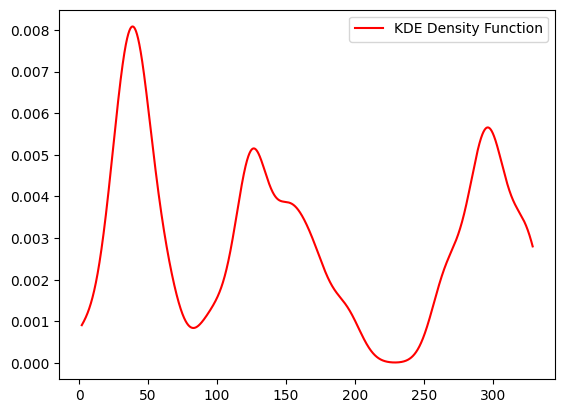

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

images, depths, pose_strs = dataset[0]
data = np.array([int(os.path.split(i)[1].split('.')[0]) for i in images])

# 1. Fit the KDE to your data
kde = stats.gaussian_kde(data, bw_method=0.1)

# 2. Create a grid of points where you want to evaluate the density
x_eval = np.linspace(min(data), max(data), 10000)

# 3. Evaluate the density function at those points
density_values = kde(x_eval)

# Plotting the result
plt.plot(x_eval, density_values, label='KDE Density Function', color='red')
# plt.hist(data, density=True, bins=100, alpha=0.3, label='Data Histogram')
plt.legend()
plt.show()

In [8]:
len(dataset.spaths)

18634

In [9]:
random.seed(42)

In [ ]:
for i in random.sample(list(range(len(dataset))), 5):
    s = dataset[i]
    for t in s.sources, s.targets:
        for k, v in t.items():
            t[k] = v.shape if isinstance(v, torch.Tensor) else v
    print(s.scene_name)


In [138]:
import torch
import torch.nn as nn
import einx
import torchvision.transforms.v2 as T
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights, vgg19, VGG19_Weights
import torchvision.transforms.functional as VF

In [151]:
weights = ConvNeXt_Tiny_Weights.DEFAULT
model = convnext_tiny(weights=weights)
layers = list(model.features)

In [152]:
model

ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=

In [155]:
weights = VGG19_Weights.DEFAULT
model = vgg19(weights=weights)
layers = list(model.features)

In [140]:
a = torch.ones(1, 3, 224, 224)
a.mean()

tensor(1.)

In [156]:
[i for i in layers if isinstance(i, torch.nn.MaxPool2d)]

[MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False),
 MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False),
 MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False),
 MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False),
 MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)]

In [154]:
layers

[Conv2dNormActivation(
   (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
   (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
 ),
 Sequential(
   (0): CNBlock(
     (block): Sequential(
       (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
       (1): Permute()
       (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
       (3): Linear(in_features=96, out_features=384, bias=True)
       (4): GELU(approximate='none')
       (5): Linear(in_features=384, out_features=96, bias=True)
       (6): Permute()
     )
     (stochastic_depth): StochasticDepth(p=0.0, mode=row)
   )
   (1): CNBlock(
     (block): Sequential(
       (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
       (1): Permute()
       (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
       (3): Linear(in_features=96, out_features=384, bias=True)
       (4): GELU(approximate='none')
       (5): Linear(in_features=384, out_feat

In [141]:
def normalize_vec(s, t):
    mi, ma = einx.min(s, t), einx.max(s, t)
    return (t - mi) / (ma - mi)

In [147]:
layers[0].weight.data = torch.ones_like(layers[0].weight.data) / layers[0].weight.data.shape[-3:].numel()
layers[0].bias.data = torch.zeros_like(layers[0].bias.data)

In [142]:
bak = layers[0].weight.data.clone()
bak.shape
# layers[0].weight.data = bak

torch.Size([64, 3, 3, 3])

In [133]:
layers[0].weight.data = normalize_vec('o i h w -> o 1 1 1', layers[0].weight.data)

In [ ]:
# out, in, h, w
layers[0].weight.shape
#weight_bak = layers[0].weight


In [ ]:
a2 = layers[0](a)
a2min, a2max = einx.min('b c h w -> b c 1 1', a2), einx.max('b c h w -> b c 1 1', a2)
a2.shape, a2min[..., 0, 0], a2max[..., 0, 0]

(torch.Size([1, 64, 224, 224]),
 tensor([[0.4444, 0.4444, 0.4444, 0.4444, 0.4444, 0.4444, 0.4444, 0.4444, 0.4444,
          0.4444, 0.4444, 0.4444, 0.4444, 0.4444, 0.4444, 0.4444, 0.4444, 0.4444,
          0.4444, 0.4444, 0.4444, 0.4444, 0.4444, 0.4444, 0.4444, 0.4444, 0.4444,
          0.4444, 0.4444, 0.4444, 0.4444, 0.4444, 0.4444, 0.4444, 0.4444, 0.4444,
          0.4444, 0.4444, 0.4444, 0.4444, 0.4444, 0.4444, 0.4444, 0.4444, 0.4444,
          0.4444, 0.4444, 0.4444, 0.4444, 0.4444, 0.4444, 0.4444, 0.4444, 0.4444,
          0.4444, 0.4444, 0.4444, 0.4444, 0.4444, 0.4444, 0.4444, 0.4444, 0.4444,
          0.4444]], grad_fn=<SelectBackward0>),
 tensor([[1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
          1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
          1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
          1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
          1.0000, 

In [106]:
a3 = (a2 - a2min) / (a2max - a2min)
a3min, a3max = einx.min('b c h w -> b c', a3), einx.max('b c h w -> b c', a3)
a3.shape
a3min, a3max

(tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],
        grad_fn=<ViewBackward0>),
 tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
          1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
          1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
          1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]], grad_fn=<ViewBackward0>))

In [ ]:
layers[0](a).mean()

tensor(0.0004, grad_fn=<MeanBackward0>)

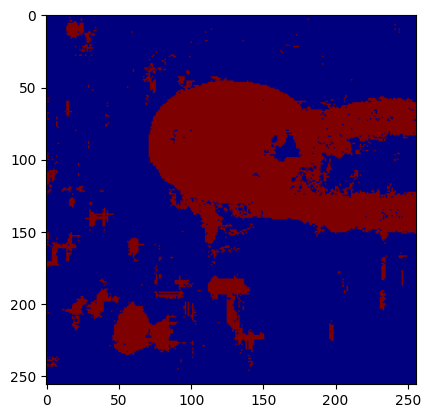

In [ ]:
from utils.io import get_image
import matplotlib.pyplot as plt

a, _, _, _ = get_image('data/co3d_new/co3d_data/new/ball/113_13374_24686/depths/frame000001.jpg.geometric.png', True, (256, 256))
a.shape

plt.imshow((a.float().cpu() > 0).permute(1, 2, 0).numpy(), cmap='jet')

# plt.hist(a.cpu().flatten()[a.float().cpu().flatten() > 0].numpy(), bins=100)

In [ ]:
import os
import json
import torch
import einx
from utils.visualization import plot_trajectory

# in co3d x y z is right up backward
co3d_path = 'data/co3d_new/co3d_data/co3d'
with open(os.path.join(co3d_path, 'bench/167_18175_33897/transforms.json'), 'r') as f:
    T_co3d = torch.stack([torch.tensor(t['transform_matrix']) for t in json.load(f)['frames']])
    P1 = torch.eye(4)
    P1[1, 1], P1[2, 2] = -1, -1
    P2 = torch.eye(4)
    P2[1, 1], P2[2, 2] = 0, 0
    P2[2, 1], P2[1, 2] = 1, -1
    T_co3d = P2 @ T_co3d @ P1

# in wildrgbd x y z is right down forward
wildrgbd_path = 'data/wildrgbd'
with open(os.path.join(wildrgbd_path, 'apple/scenes/scene_001/cam_poses.txt'), 'r') as f:
    T_wildrgbd = torch.stack([torch.tensor([float(i) for i in l.strip().split(' ')[1:]]).reshape(4, 4) for l in f.read().split('\n')])
    # P = torch.eye(4)
    # P[1, 1] = 1
    # P[1, 2] = 0.33
    # T_wildrgbd = P @ T_wildrgbd

for T, forward in ((T_co3d, [0.0, 0.0, 1.0]), (T_wildrgbd, [0.0, 0.0, 1.0])):
    R, t = T[:, :3, :3], T[:, :3, 3]
    dirs = (R @ torch.tensor([forward] * T.shape[0]).unsqueeze(-1)).squeeze(-1)
    colors = torch.zeros(T.shape[0], 3)
    colors[:2, 0] = 1
    colors[30:32, [1, 2]] = 0.7

    plot_trajectory(t, dirs, colors, d_scale=0.04)


In [3]:
import torch
from utils.visualization import plot_trajectory

# 1. Create a dummy PyTorch tensor of shape (N, 3) representing (X, Y, Z)
# Replace this with your actual trajectory tensor
num_points = 100
t = torch.linspace(0, 20, num_points)
x = torch.sin(t)
y = torch.cos(t)
z = t / 10
traj = torch.stack([x, y, z], dim=-1)
end = torch.stack([torch.zeros_like(x), torch.zeros_like(y), torch.zeros_like(z)], dim=-1)
dirs = end - traj
plot_trajectory(traj, dirs, d_scale=0.2)

In [ ]:
import torch
import os
from PIL import Image
import torchvision.transforms.functional as VF
from utils.data import normalize_depths
import math


def listdirs(path):
    return [os.path.join(path, i) for i in os.listdir(path) if os.path.isdir(os.path.join(path, i))]


def listfiles(path):
    return [os.path.join(path, i) for i in os.listdir(path) if os.path.isfile(os.path.join(path, i))]


path = 'data/wildrgbd/'
dpaths = [d for p in listdirs(path) for s in listdirs(os.path.join(p, 'scenes')) for c in listdirs(os.path.join(s, 'cones')) for d in listfiles(os.path.join(c, 'depth'))]
dpathss = dpaths
d_min, d_max = 0.01, 1000.0
d_min_log, d_max_log = math.log(d_min), math.log(d_max)
transform = lambda x: x.log()
transform2 = lambda x: normalize_depths(x, d_min_log, d_max_log)

# depths
# means, stds = [torch.stack(i) for i in zip(*[(lambda x: (x.mean(), x.std()))((lambda x: transform(x[x > 0]))(VF.pil_to_tensor(Image.open(d)) / 1000.0)) for d in dpathss])]

# depth masks
means, stds = [torch.stack(i) for i in zip(*[(lambda x: (x.mean(), x.std()))((lambda x: torch.where(x > 0, 1.0, 0.0))(VF.pil_to_tensor(Image.open(d)) / 1000.0)) for d in dpathss])]
#torch.save({'means': means, 'stds': stds}, './Desktop/a.pt')
mean = means.mean()
std = (stds.square().mean() + (means - mean).square().mean()).sqrt()
mean, std

In [ ]:
from dataset.co3d_eval import CO3DEvalDataset

val_dataset = CO3DEvalDataset(
    path='data/co3d_data/eval/',
    split='3'
)

In [13]:
val_dataset[0].sources.keys(), val_dataset[0].sources.images.shape

(dict_keys(['K', 'R', 't', 'images', 'depths', 'depth_masks']),
 torch.Size([3, 3, 256, 256]))